In [5]:
# Restore all previously stored variables
%store -r plots_dir hygrolon_area c_hygrolon n_hygrolon isopod_c_n_ratio isopod_c isopod_n springtail_c_n_ratio springtail_c springtail_n 
%store -r moss_c_n_ratio moss_c moss_n

In [6]:
# Import the below libraries:
"""For faster loading, consider importing the libraries in separate cells."""
# To create reproducible file paths
import os # To interact with the operating system
from pathlib import Path # To create Path objects
import pathlib # To access the object-oriented library for paths

# For scientific computing
import numpy as np # To work with arrays
from scipy.integrate import odeint # To solve ordinary differential equations (ODEs)

# For visualization and interactive plotting
import matplotlib.pyplot as plt # To import the Pyplot module

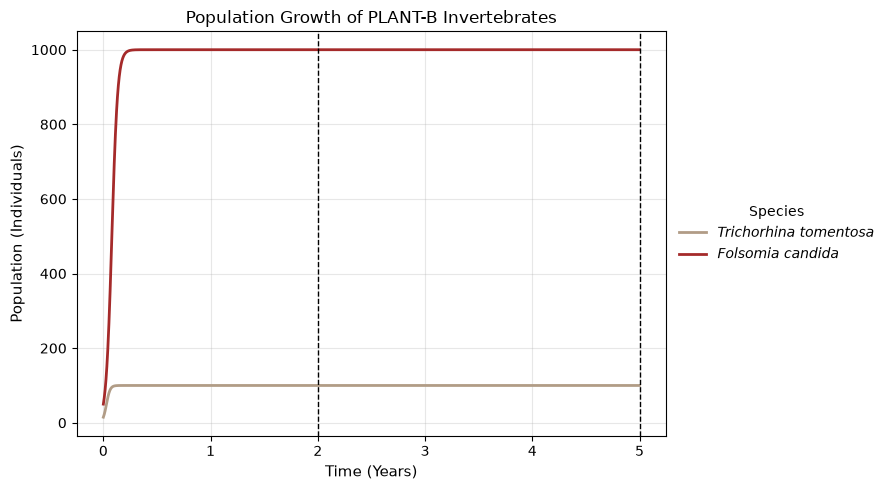

In [7]:
# Give the timeframe (in days)
total_days = 365 * 5 # Five years in total
t = np.arange(total_days)

# Define population parameters for the two invertebrates:
# Isopod population parameters
isopods = 15 # Starting number of isopod individuals
isopod_carrying_capacity = 100 # Placeholder isopod carrying capacity for the terrarium
isopod_fecundity = 0.164 # Average daily fecundity (by eggs laid) of a close relative (Heeley, 1941)
isopod_mortality = 0.0011 # Calculated from an assumed average lifespan of 2.5 years

# Model the isopod population growth over time
isopod_growth_rate = isopod_fecundity - isopod_mortality # Define the daily growth rate for the isopods
isopod_population = isopod_carrying_capacity / (1 + ((isopod_carrying_capacity - isopods) / isopods) * np.exp(-isopod_growth_rate * t))

# Springtail population parameters
springtails = 50 # Starting number of springtail individuals
springtail_carrying_capacity = 1000 # Placeholder springtail carrying capacity for the terrarium
springtail_fecundity = 0.109 # Average daily fecundity of adult springtails (Xie et al., 2026)
springtail_mortality = 0.00734 # Average daily mortality of the springtails at 21°C (Snider & Butcher, 1973)

# Model the springtail population growth over time
springtail_growth_rate = springtail_fecundity - springtail_mortality # Define the daily growth rate for the springtails
springtail_population = springtail_carrying_capacity / (1 + ((springtail_carrying_capacity - springtails) / springtails) * 
                                                        np.exp(-springtail_growth_rate * t))

# Create a function that plots the invertebrate population growth over five years:
def population_growth_plot(t, isopod_population, springtail_population):
    """
    Parameters:
    t (array): Time values in days across five years
    isopod_population: Growing isopod population count over time
    springtail_population: Growing springtail population count over time

    Returns:
    A line chart that shows the isopod and springtail population growth curves over the five-year timeframe
    """
    # Label the population curves and set their colors
    species_colors = {
        "Trichorhina tomentosa": "#B19C86", # Weathered wood the white dwarf isopod
        # Dark orange for the temperate white springtail
        "Folsomia candida": "#A52A2A" # Reddish-brown for the temperate white springtail
    }

    # Convert the day-based time array to years for the x-axis
    years = t / 365

    # Create the figure
    fig, ax = plt.subplots(figsize=(9, 5))

    # Plot the isopod population growth curve
    ax.plot(
        years,
        isopod_population,
        color=species_colors["Trichorhina tomentosa"], # Ensure the isopod keeps its designated color
        label=r"$\it{Trichorhina\ tomentosa}$", # Italicize the isopod's scientific name
        linewidth=2
    )

    # Plot the springtail population growth curve
    ax.plot(
        years,
        springtail_population,
        color=species_colors["Folsomia candida"], # Ensure the springtail keeps its designated color
        label=r"$\it{Folsomia\ candida}$", # Italicize the springtail's scientific name
        linewidth=2
    )

    # Set the title
    ax.set_title("Population Growth of PLANT-B Invertebrates", fontsize=12)

    # Label the x- and y-axis and set their font size
    ax.set_xlabel("Time (Years)", fontsize=11)
    ax.set_ylabel("Population (Individuals)", fontsize=11)

    # Mark the two- and five-year intervals on the plot
    plt.axvline(2, color='black', linestyle='--', linewidth=1) # For two years
    plt.axvline(5, color='black', linestyle='--', linewidth=1) # For five years

    # Create a legend titled "Species" and anchor it to the right
    ax.legend(title='Species', loc='center left', bbox_to_anchor=(1.0, 0.5), frameon=False)

    # Add gridlines for readability
    ax.grid(True, alpha=0.3)

    # Apply a tight layout
    plt.tight_layout()

    # Save the plot as a png image to the "plots" folder
    plt.savefig(
        os.path.join(plots_dir, "PLANT-B_Invertebrate_Population_Growth_Plot.png"),
        dpi=300,
        bbox_inches="tight"
    )

    # Display the plot
    plt.show()

    # Return the figure and axes
    return fig, ax

# Call the function
fig, ax = population_growth_plot(
    t,
    isopod_population,
    springtail_population
)

In [ ]:
# Define fixed conditons
whc = 0.60 # Target water holding capacity (WHC) of 60%

# Define population parameters for the three species:
# Moss population parameters
moss_mass = 0.00344827586 * hygrolon_area # Moss mass per cm² calculated from given mass in a 90 mm diameter Petri dish (Cove et al., 2009)
moss_c_intake_rate = 0.000070954 * t # Daily carbon uptake of moss taken from given CO² uptake (Douma et al., 2007)
moss_n_deposition_rate = 0.00000051 * t # Average nitrogen uptake rate for mosses (Ayres et al., 2006)


# Calculate starting moss carbon (g)
starting_moss_c = moss_mass * (moss_c / 100) # Starting carbon quantity of 0.30620689636 g

# Calculate starting moss nitrogen (g)
starting_moss_n = moss_mass * (moss_n / 100) # Starting nitrogen quantity of 0.00868965516 g

# Isopod population parameters
isopod_mass = 0.04355 # Average mass (g) of a close relative of the isopod (Bílá et al., 2014)
isopod_consumption = 0.00166 # Average daily litter consumption (g) of a close relative of the isopod (Bílá et al., 2014)
isopod_n_excretion = 0.0000008922 # Average daily nitrogen excretion (g) of a close relative of the isopod (Weiser & Schweizer, 1970)

# Calculate starting isopod carbon (g)
starting_moss_c = isopod_mass * isopods * (isopod_c / 100) # Starting carbon quantity of 0.30620689636 g

# Calculate starting moss nitrogen (g)
starting_moss_n = moss_mass * (moss_n / 100) # Starting nitrogen quantity of 0.00868965516 g

# Calculate starting isopod carbon (g)
starting_isopod_c = isopods * isopod_mass * (isopod_c / 100) 

# Calculate starting isopod nitrogen (g)
starting_isopod_n = isopods * isopod_mass * (isopod_n / 100)

SyntaxError: invalid syntax (2779374131.py, line 19)

Data Sources

Ayres, E., van der Wal, R., Sommerkorn, M., & Bardgett, R. D. (2006). Direct uptake of soil nitrogen by mosses. *Biology Letters*, 2(2), 286–288. https://doi.org/10.1098/rsbl.2006.0455

Bílá, K., Moretti, M., de Bello, F., Dias, A. T. C., Pezzatti, G. B., Van Oosten, A. R., & Berg, M. P. (2014). Disentangling community functional components in a litter‐macrodetritivore model system reveals the predominance of the mass ratio hypothesis. *Ecology and Evolution*, *4*(4), 408–416. https://doi.org/10.1002/ece3.941

Cove, D. J., Perroud, P.-F., Charron, A. J., McDaniel, S. F., Khandewal, A, & Quatrano, R. S. The moss *Physcomitrella patens*: a novel model system for plant development and genomic studies. *Cold Spring Harbor Protocols*, *4*(2), pdb.emo115. http://doi.org/10.1101/pdb.emo115

Douma, J. C., VAN Wijk, M. T., Lang, S. I., & Shaver, G. R. (2007). The contribution of mosses to the carbon and water exchange of Arctic ecosystems: quantification and relationships with system properties. *Plant, Cell & Environment*, *30*(10), 1205–1215. https://doi.org/10.1111/j.1365-3040.2007.01697.x

Heeley, W. (1941). Observations on the Life-Histories of some Terrestrial Isopods. *Proceedings of the Zoological Society of London*, *B111*(1–2), 79–149. https://doi.org/10.1111/j.1469-7998.1941.tb00044.x

Snider, R. M., & Butcher, J. W. (1973). The Life History of *Folsomia Candida* (Willem) (Collembola: Isotomidae) Relative to Temperature. *The Great Lakes Entomologist*, *6*(4), 97-106. https://doi.org/10.22543/0090-0222.1187

Wieser, W., & Schweizer, G. (1970). A Re-Examination of the Excretion of Nitrogen by Terrestrial Isopods. *Journal of Experimental Biology*, *52*(2), 267–274. https://doi.org/10.1242/jeb.52.2.267

Xie, L., Duan, X., Norouzi, S., de Jonge, L. W., & Topping, C. J. (2026). Integrating spatial and environmental stressors in a population model of *Folsomia candida* (Collembola, Isotomidae): a Formal Model within ALMaSS framework. *Agricultural and Environmental Modelling*, *8*, e184962. https://doi.org/10.3897/aem.8.184962